# 📊 YOLO 답안 인식 정확도 분석

## 개요
- **results_summary.txt**: 이미지 파일, 페이지 번호, 문제 번호, 정답
- **yolo_answer.txt**: 페이지번호, 문제 번호, 정답 (정답지)

정답지를 기준으로 인식 결과를 비교하여 정확도를 계산합니다.

In [25]:
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


## 1. 파일 경로 설정

In [26]:
# 파일 경로 설정 (필요시 수정)
results_path = Path("results_summary.txt")
answer_key_path = Path("yolo_answer.txt")
output_dir = Path("./")

# 파일 존재 확인
if not results_path.exists():
    print(f"❌ 파일을 찾을 수 없습니다: {results_path}")
else:
    print(f"✅ Results 파일: {results_path}")

if not answer_key_path.exists():
    print(f"❌ 파일을 찾을 수 없습니다: {answer_key_path}")
else:
    print(f"✅ Answer Key 파일: {answer_key_path}")

✅ Results 파일: results_summary.txt
✅ Answer Key 파일: yolo_answer.txt


## 2. 데이터 로드 및 전처리

In [27]:
def load_results(file_path: Path) -> pd.DataFrame:
    """results_summary.txt 로드
    형식: 이미지파일, 페이지번호, 문제번호, 정답
    """
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            
            parts = [p.strip() for p in line.split(',')]
            if len(parts) >= 4:
                data.append({
                    'image_file': parts[0],
                    'page_number': parts[1],
                    'problem_number': parts[2],
                    'predicted_answer': parts[3] if parts[3].lower() != 'none' else None
                })
            else:
                print(f"⚠️ Warning: 라인 {line_num} 형식 오류: {line}")
    
    df = pd.DataFrame(data)
    print(f"\n📄 Results Summary 로드 완료: {len(df)}개 항목")
    print(f"   - None 답안: {df['predicted_answer'].isna().sum()}개")
    return df

def load_answer_key(file_path: Path) -> pd.DataFrame:
    """yolo_answer.txt 로드 (정답지)
    형식: 페이지번호, 문제번호, 정답
    """
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            
            parts = [p.strip() for p in line.split(',')]
            if len(parts) >= 3:
                data.append({
                    'page_number': parts[0],
                    'problem_number': parts[1],
                    'correct_answer': parts[2]
                })
            else:
                print(f"⚠️ Warning: 라인 {line_num} 형식 오류: {line}")
    
    df = pd.DataFrame(data)
    print(f"\n📘 Answer Key 로드 완료: {len(df)}개 항목")
    return df

# 데이터 로드
results_df = load_results(results_path)
answer_key_df = load_answer_key(answer_key_path)

print("\n" + "="*60)


📄 Results Summary 로드 완료: 155개 항목
   - None 답안: 0개

📘 Answer Key 로드 완료: 155개 항목



## 3. 데이터 샘플 확인

## 4. 정답 비교 및 정확도 계산

In [28]:
# 정답지를 기준으로 results와 merge
merged_df = answer_key_df.merge(
    results_df,
    on=['page_number', 'problem_number'],
    how='left',
    indicator=True
)

# 비교 결과 컬럼 추가
def compare_answers(row):
    """정답 비교"""
    if row['_merge'] == 'left_only':
        return 'missing'  # results에 없음
    elif pd.isna(row['predicted_answer']):
        return 'none'  # None으로 예측됨
    elif str(row['predicted_answer']).strip() == str(row['correct_answer']).strip():
        return 'correct'  # 정답
    else:
        return 'wrong'  # 오답

merged_df['result'] = merged_df.apply(compare_answers, axis=1)

print("\n✅ 정답 비교 완료")
print("\n📊 전체 결과:")
display(merged_df.head(20))


✅ 정답 비교 완료

📊 전체 결과:


,page_number,problem_number,correct_answer,image_file,predicted_answer,_merge,result
0,9,01,1,학생이 푼 문제(유형편) - 1,1,both,correct
1,10,02,2,학생이 푼 문제(유형편) - 2,2,both,correct
2,11,03,2,학생이 푼 문제(유형편) - 3,2,both,correct
3,12,04,4,학생이 푼 문제(유형편) - 4,4,both,correct
4,13,05,1,학생이 푼 문제(유형편) - 5,1,both,correct
5,15,01,4,학생이 푼 문제(유형편) - 6,4,both,correct
6,16,02,5,학생이 푼 문제(유형편) - 7,5,both,correct
7,17,03,1,학생이 푼 문제(유형편) - 8,1,both,correct
8,18,04,3,학생이 푼 문제(유형편) - 9,3,both,correct
9,19,05,2,학생이 푼 문제(유형편) - 10,2,both,correct


## 5. 정확도 통계

In [29]:
# 결과별 개수 계산
total_count = len(merged_df)
correct_count = (merged_df['result'] == 'correct').sum()
wrong_count = (merged_df['result'] == 'wrong').sum()
none_count = (merged_df['result'] == 'none').sum()
missing_count = (merged_df['result'] == 'missing').sum()

# 정확도 계산
accuracy = correct_count / total_count * 100 if total_count > 0 else 0

# 인식 성공률 (None 제외)
recognized_count = total_count - missing_count
recognition_rate = recognized_count / total_count * 100 if total_count > 0 else 0

# 인식된 것 중 정확도
accuracy_of_recognized = correct_count / recognized_count * 100 if recognized_count > 0 else 0

print("="*60)
print("📊 정확도 통계")
print("="*60)
print(f"\n📘 정답지 기준:")
print(f"   총 문제 수: {total_count}개")
print(f"\n✅ 정답: {correct_count}개 ({correct_count/total_count*100:.2f}%)")
print(f"❌ 오답: {wrong_count}개 ({wrong_count/total_count*100:.2f}%)")
print(f"⚠️ None: {none_count}개 ({none_count/total_count*100:.2f}%)")
print(f"🔍 누락: {missing_count}개 ({missing_count/total_count*100:.2f}%)")
print(f"\n{'='*60}")
print(f"🎯 전체 정확도: {accuracy:.2f}%")
print(f"📝 인식 성공률 (누락 제외): {recognition_rate:.2f}%")
print(f"✨ 인식된 것 중 정확도 (None 포함): {accuracy_of_recognized:.2f}%")
print("="*60)

📊 정확도 통계

📘 정답지 기준:
   총 문제 수: 155개

✅ 정답: 154개 (99.35%)
❌ 오답: 1개 (0.65%)
⚠️ None: 0개 (0.00%)
🔍 누락: 0개 (0.00%)

🎯 전체 정확도: 99.35%
📝 인식 성공률 (누락 제외): 100.00%
✨ 인식된 것 중 정확도 (None 포함): 99.35%


## 6. 시각화


📊 Visualization saved: accuracy_visualization.png


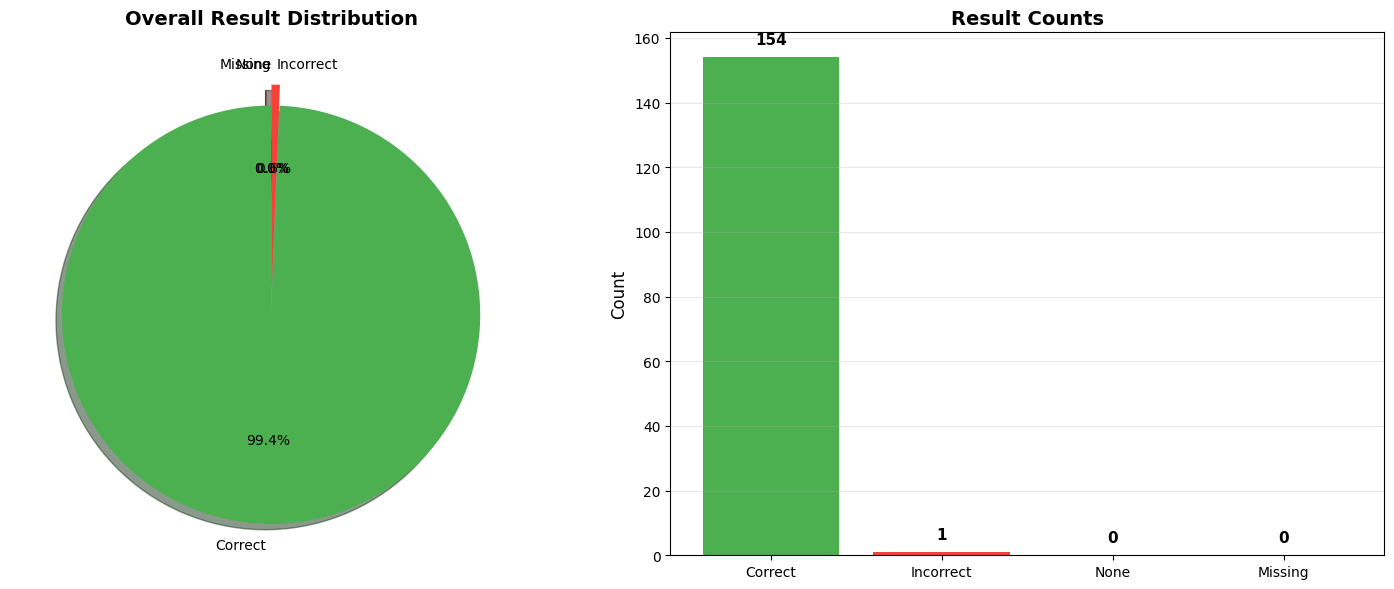

In [30]:
import matplotlib.pyplot as plt

# 결과 분포 파이 차트
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie Chart 1: Overall Results
labels = ['Correct', 'Incorrect', 'None', 'Missing']
sizes = [correct_count, wrong_count, none_count, missing_count]
colors = ['#4CAF50', '#F44336', '#FF9800', '#9E9E9E']
explode = (0.1, 0, 0, 0)

axes[0].pie(
    sizes, explode=explode, labels=labels, colors=colors,
    autopct='%1.1f%%', shadow=True, startangle=90
)
axes[0].set_title('Overall Result Distribution', fontsize=14, fontweight='bold')

# Bar Chart: Counts
categories = ['Correct', 'Incorrect', 'None', 'Missing']
counts = [correct_count, wrong_count, none_count, missing_count]
axes[1].bar(categories, counts, color=colors)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Result Counts', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(counts):
    axes[1].text(i, v + max(counts) * 0.02, str(v),
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir / 'accuracy_visualization.png', dpi=300, bbox_inches='tight')
print(f"\n📊 Visualization saved: {output_dir / 'accuracy_visualization.png'}")
plt.show()


## 7. 누락된 문제 분석

In [31]:
# 누락된 문제 (정답지에는 있지만 results에 없는 경우)
missing_df = merged_df[merged_df['result'] == 'missing'].copy()

print("="*60)
print(f"🔍 누락된 문제 분석 (총 {len(missing_df)}개)")
print("="*60)

if len(missing_df) > 0:
    print("\n누락된 문제 목록:")
    display(missing_df[['page_number', 'problem_number', 'correct_answer']].sort_values(['page_number', 'problem_number']))
    
    # 페이지별 누락 통계
    print("\n📄 페이지별 누락 통계:")
    page_missing = missing_df.groupby('page_number').size().reset_index(name='missing_count')
    page_missing = page_missing.sort_values('missing_count', ascending=False)
    display(page_missing)
else:
    print("\n✅ 누락된 문제가 없습니다!")

🔍 누락된 문제 분석 (총 0개)

✅ 누락된 문제가 없습니다!


## 8. None 답안 분석

In [32]:
# None으로 인식된 문제
none_df = merged_df[merged_df['result'] == 'none'].copy()

print("="*60)
print(f"⚠️ None 답안 분석 (총 {len(none_df)}개)")
print("="*60)

if len(none_df) > 0:
    print("\nNone으로 인식된 문제 목록:")
    display(none_df[['page_number', 'problem_number', 'correct_answer', 'image_file']].sort_values(['page_number', 'problem_number']))
    
    # 페이지별 None 통계
    print("\n📄 페이지별 None 통계:")
    page_none = none_df.groupby('page_number').size().reset_index(name='none_count')
    page_none = page_none.sort_values('none_count', ascending=False)
    display(page_none)
else:
    print("\n✅ None 답안이 없습니다!")

⚠️ None 답안 분석 (총 0개)

✅ None 답안이 없습니다!


## 9. 오답 분석

In [33]:
# 오답
wrong_df = merged_df[merged_df['result'] == 'wrong'].copy()

print("="*60)
print(f"❌ 오답 분석 (총 {len(wrong_df)}개)")
print("="*60)

if len(wrong_df) > 0:
    print("\n오답 목록:")
    display(wrong_df[['page_number', 'problem_number', 'correct_answer', 'predicted_answer', 'image_file']].sort_values(['page_number', 'problem_number']))
    
    # 페이지별 오답 통계
    print("\n📄 페이지별 오답 통계:")
    page_wrong = wrong_df.groupby('page_number').size().reset_index(name='wrong_count')
    page_wrong = page_wrong.sort_values('wrong_count', ascending=False)
    display(page_wrong.head(10))
else:
    print("\n✅ 오답이 없습니다!")

❌ 오답 분석 (총 1개)

오답 목록:


,page_number,problem_number,correct_answer,predicted_answer,image_file
113,105,04,4,5,학생이 푼 문제(실전 모의고사) - 18



📄 페이지별 오답 통계:


,page_number,wrong_count
0,105,1


## 10. 페이지별 정확도

In [34]:
# 페이지별 정확도 계산
page_stats = merged_df.groupby('page_number').agg({
    'result': 'count',
}).rename(columns={'result': 'total'})

page_stats['correct'] = merged_df[merged_df['result'] == 'correct'].groupby('page_number').size()
page_stats['wrong'] = merged_df[merged_df['result'] == 'wrong'].groupby('page_number').size()
page_stats['none'] = merged_df[merged_df['result'] == 'none'].groupby('page_number').size()
page_stats['missing'] = merged_df[merged_df['result'] == 'missing'].groupby('page_number').size()

page_stats = page_stats.fillna(0).astype(int)
page_stats['accuracy'] = (page_stats['correct'] / page_stats['total'] * 100).round(2)
page_stats = page_stats.sort_values('accuracy', ascending=False)

print("="*60)
print("📊 페이지별 정확도")
print("="*60)
display(page_stats)

# 정확도가 낮은 페이지
print("\n⚠️ 정확도가 낮은 페이지 (80% 미만):")
low_accuracy_pages = page_stats[page_stats['accuracy'] < 80]
if len(low_accuracy_pages) > 0:
    display(low_accuracy_pages)
else:
    print("✅ 모든 페이지가 80% 이상의 정확도를 보입니다!")

📊 페이지별 정확도


,total,correct,wrong,none,missing,accuracy
page_number,,,,,,
10,1,1,0,0,0,100.0
100,2,2,0,0,0,100.0
101,2,2,0,0,0,100.0
102,2,2,0,0,0,100.0
103,2,2,0,0,0,100.0
...,...,...,...,...,...,...
95,2,2,0,0,0,100.0
98,2,2,0,0,0,100.0
97,2,2,0,0,0,100.0



⚠️ 정확도가 낮은 페이지 (80% 미만):
✅ 모든 페이지가 80% 이상의 정확도를 보입니다!


## 11. 결과 저장

In [35]:
# 상세 결과 저장
detailed_results_path = output_dir / "detailed_comparison.csv"
merged_df.to_csv(detailed_results_path, index=False, encoding='utf-8-sig')
print(f"\n💾 상세 비교 결과 저장: {detailed_results_path}")

# 페이지별 통계 저장
page_stats_path = output_dir / "page_statistics.csv"
page_stats.to_csv(page_stats_path, encoding='utf-8-sig')
print(f"💾 페이지별 통계 저장: {page_stats_path}")

# 요약 리포트 저장
summary_path = output_dir / "accuracy_summary.txt"
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("YOLO 답안 인식 정확도 분석 보고서\n")
    f.write("="*60 + "\n\n")
    
    f.write("📊 전체 통계\n")
    f.write("-"*60 + "\n")
    f.write(f"총 문제 수: {total_count}개\n")
    f.write(f"정답: {correct_count}개 ({correct_count/total_count*100:.2f}%)\n")
    f.write(f"오답: {wrong_count}개 ({wrong_count/total_count*100:.2f}%)\n")
    f.write(f"None: {none_count}개 ({none_count/total_count*100:.2f}%)\n")
    f.write(f"누락: {missing_count}개 ({missing_count/total_count*100:.2f}%)\n\n")
    
    f.write("="*60 + "\n")
    f.write(f"🎯 전체 정확도: {accuracy:.2f}%\n")
    f.write(f"📝 인식 성공률 (누락 제외): {recognition_rate:.2f}%\n")
    f.write(f"✨ 인식된 것 중 정확도: {accuracy_of_recognized:.2f}%\n")
    f.write("="*60 + "\n\n")
    
    if len(missing_df) > 0:
        f.write(f"\n🔍 누락된 문제: {len(missing_df)}개\n")
        f.write("-"*60 + "\n")
        for _, row in missing_df.iterrows():
            f.write(f"페이지 {row['page_number']}, 문제 {row['problem_number']}, 정답 {row['correct_answer']}\n")
    
    if len(none_df) > 0:
        f.write(f"\n⚠️ None 답안: {len(none_df)}개\n")
        f.write("-"*60 + "\n")
        for _, row in none_df.head(20).iterrows():
            f.write(f"페이지 {row['page_number']}, 문제 {row['problem_number']}, 정답 {row['correct_answer']}\n")
        if len(none_df) > 20:
            f.write(f"... 외 {len(none_df)-20}개\n")
    
    if len(wrong_df) > 0:
        f.write(f"\n❌ 오답: {len(wrong_df)}개\n")
        f.write("-"*60 + "\n")
        for _, row in wrong_df.head(20).iterrows():
            f.write(f"페이지 {row['page_number']}, 문제 {row['problem_number']}, 정답 {row['correct_answer']}, 예측 {row['predicted_answer']}\n")
        if len(wrong_df) > 20:
            f.write(f"... 외 {len(wrong_df)-20}개\n")

print(f"💾 요약 리포트 저장: {summary_path}")

print("\n" + "="*60)
print("✅ 모든 분석이 완료되었습니다!")
print("="*60)


💾 상세 비교 결과 저장: detailed_comparison.csv
💾 페이지별 통계 저장: page_statistics.csv
💾 요약 리포트 저장: accuracy_summary.txt

✅ 모든 분석이 완료되었습니다!


## 12. 최종 요약

In [36]:
from IPython.display import Markdown, display

summary_md = f"""
# 📊 최종 분석 요약

## 🎯 전체 정확도: **{accuracy:.2f}%**

---

### 📈 주요 지표
- **인식 성공률**: {recognition_rate:.2f}% (누락 제외)
- **인식된 것 중 정확도**: {accuracy_of_recognized:.2f}%

---

### 📊 상세 통계
| 구분 | 개수 | 비율 |
|------|------|------|
| ✅ 정답 | {correct_count}개 | {correct_count/total_count*100:.2f}% |
| ❌ 오답 | {wrong_count}개 | {wrong_count/total_count*100:.2f}% |
| ⚠️ None | {none_count}개 | {none_count/total_count*100:.2f}% |
| 🔍 누락 | {missing_count}개 | {missing_count/total_count*100:.2f}% |
| **📘 전체** | **{total_count}개** | **100.00%** |

---

### 💡 개선 포인트
""" 

if missing_count > 0:
    summary_md += f"\n- 🔍 **누락 문제 해결**: {missing_count}개 문제가 results에 없습니다. Section 검출 문제일 수 있습니다."

if none_count > 0:
    summary_md += f"\n- ⚠️ **None 답안 개선**: {none_count}개 문제의 답안이 인식되지 않았습니다. `none_debug_analysis.txt` 파일을 확인하세요."

if wrong_count > 0:
    summary_md += f"\n- ❌ **오답 분석**: {wrong_count}개 문제의 답안이 잘못 인식되었습니다. IoU threshold나 모델 성능을 개선하세요."

if accuracy >= 95:
    summary_md += "\n\n### 🎉 우수한 성능!"
    summary_md += "\n95% 이상의 정확도를 달성했습니다!"
elif accuracy >= 90:
    summary_md += "\n\n### 👍 양호한 성능"
    summary_md += "\n90% 이상의 정확도입니다. 조금 더 개선하면 더 좋습니다!"
else:
    summary_md += "\n\n### 🔧 개선 필요"
    summary_md += "\n정확도가 90% 미만입니다. 위의 개선 포인트를 참고하여 모델을 개선하세요."

summary_md += f"""

---

### 📁 생성된 파일
- `detailed_comparison.csv`: 전체 비교 결과
- `page_statistics.csv`: 페이지별 통계
- `accuracy_summary.txt`: 요약 리포트
- `accuracy_visualization.png`: 시각화 차트
"""

display(Markdown(summary_md))


# 📊 최종 분석 요약

## 🎯 전체 정확도: **99.35%**

---

### 📈 주요 지표
- **인식 성공률**: 100.00% (누락 제외)
- **인식된 것 중 정확도**: 99.35%

---

### 📊 상세 통계
| 구분 | 개수 | 비율 |
|------|------|------|
| ✅ 정답 | 154개 | 99.35% |
| ❌ 오답 | 1개 | 0.65% |
| ⚠️ None | 0개 | 0.00% |
| 🔍 누락 | 0개 | 0.00% |
| **📘 전체** | **155개** | **100.00%** |

---

### 💡 개선 포인트

- ❌ **오답 분석**: 1개 문제의 답안이 잘못 인식되었습니다. IoU threshold나 모델 성능을 개선하세요.

### 🎉 우수한 성능!
95% 이상의 정확도를 달성했습니다!

---

### 📁 생성된 파일
- `detailed_comparison.csv`: 전체 비교 결과
- `page_statistics.csv`: 페이지별 통계
- `accuracy_summary.txt`: 요약 리포트
- `accuracy_visualization.png`: 시각화 차트
